In [60]:
from utils.losses import *
from pathlib import Path
import pandas as pd

# assume the latest prediction is always the best prediction




avg_losses, avg_covs, avg_mae_losses = {}, {}, {}

for name in ["chronos", "linear", "tree_based"]:
    print(name.upper())
    for file in Path(f"output/{name}").rglob("*predictions.csv"):
        df = pd.read_csv(file, index_col=0)
        avg_loss = average_pinball_loss(df)
        print(f"Average pinball loss {name}: {avg_loss.mean():.2f}")
        avg_coverage = coverage_within_range(df)
        print(f"Average coverage {name}: {avg_coverage.mean():.1%}")
        mae = (df.iloc[:,0] - df.iloc[:,2]).abs()
        print(f"Mean Absolute Error: {mae.mean():.2f}")
        print("\n")
    print("----\n")

    # avg_losses[name] = avg_loss
    # avg_covs[name] = avg_coverage
    # avg_mae_losses[name] = mae

CHRONOS
Average pinball loss chronos: 2.83
Average coverage chronos: 76.1%
Mean Absolute Error: 8.87


Average pinball loss chronos: 2.80
Average coverage chronos: 81.6%
Mean Absolute Error: 9.26


Average pinball loss chronos: 3.59
Average coverage chronos: 78.1%
Mean Absolute Error: 12.10


Average pinball loss chronos: 2.79
Average coverage chronos: 76.9%
Mean Absolute Error: 8.93


----

LINEAR
Average pinball loss linear: 6.52
Average coverage linear: 76.4%
Mean Absolute Error: 18.91


Average pinball loss linear: 7.11
Average coverage linear: 76.4%
Mean Absolute Error: 22.84


----

TREE_BASED
Average pinball loss tree_based: 3.55
Average coverage tree_based: 55.4%
Mean Absolute Error: 9.78


Average pinball loss tree_based: 4.02
Average coverage tree_based: 59.5%
Mean Absolute Error: 11.57


Average pinball loss tree_based: 4.00
Average coverage tree_based: 55.5%
Mean Absolute Error: 11.17


Average pinball loss tree_based: 3.85
Average coverage tree_based: 55.0%
Mean Absolute E

### Tree-based

<>:10: SyntaxWarning: invalid escape sequence '\g'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\g'
<>:12: SyntaxWarning: invalid escape sequence '\l'
C:\Users\c.fusarbassini\AppData\Local\Temp\2\ipykernel_10060\3449357742.py:10: SyntaxWarning: invalid escape sequence '\g'
  q_min.groupby(q_min.index % 24).mean().plot(ax=ax, c="tab:red", label="True val $\geq$ Q10")
C:\Users\c.fusarbassini\AppData\Local\Temp\2\ipykernel_10060\3449357742.py:12: SyntaxWarning: invalid escape sequence '\l'
  q_max.groupby(q_max.index % 24).mean().plot(ax=ax, c="tab:green", label="True val $\leq$ Q90")
C:\Users\c.fusarbassini\AppData\Local\Temp\2\ipykernel_10060\3449357742.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(r"output\tree_based\20260420164314\predictions.csv", index_col=0, parse_dates

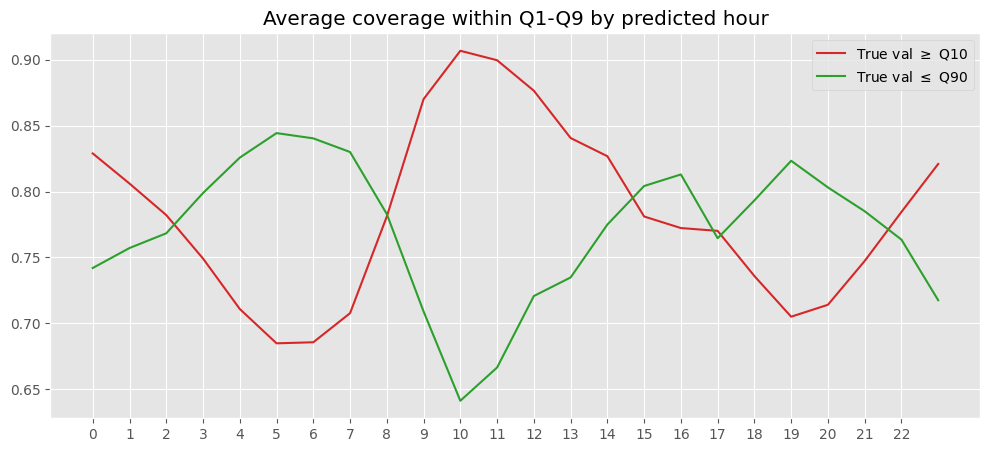

In [ ]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")

df = pd.read_csv(r"output\tree_based\20260420164314\predictions.csv", index_col=0, parse_dates=True)
q_min = quantile_coverage(df["true"], df["pred_q0.1"], 0.1, False)
q_max = quantile_coverage(df["true"], df["pred_q0.9"], 0.9, False)

fig, ax = plt.subplots(1, figsize=(12,5))
# q_min.groupby(q_min.index.hour).mean().plot(ax=ax, c="tab:red", label="True val $\geq$ Q10")
q_min.groupby(q_min.index % 24).mean().plot(ax=ax, c="tab:red", label="True val $\geq$ Q10")
# q_max.groupby(q_max.index.hour).mean().plot(ax=ax, c="tab:green", label="True val $\leq$ Q90")
q_max.groupby(q_max.index % 24).mean().plot(ax=ax, c="tab:green", label="True val $\leq$ Q90")
ax.set_title("Average coverage within Q1-Q9 by predicted hour")
_ = ax.set_xticks(range(23))
_  = ax.legend()


C:\Users\c.fusarbassini\AppData\Local\Temp\2\ipykernel_10060\1667514556.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  feat_imp = pd.read_csv(r"output\tree_based\20260420164314\feature_importances.csv", index_col=0, parse_dates=True)
C:\Users\c.fusarbassini\AppData\Local\Temp\2\ipykernel_10060\1667514556.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


Text(0, 0.5, '% of splits')

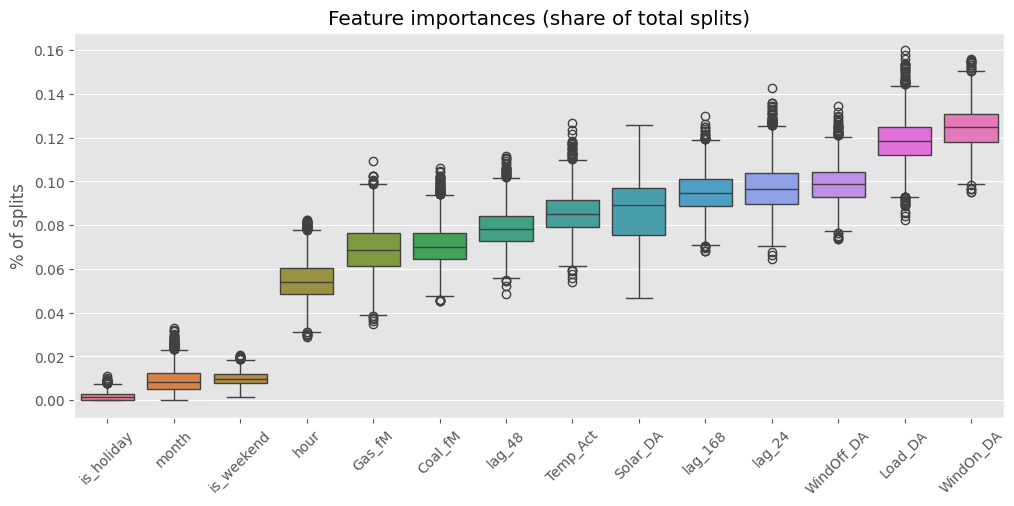

In [105]:
import seaborn as sns

feat_imp = pd.read_csv(r"output\tree_based\20260420164314\feature_importances.csv", index_col=0, parse_dates=True)
fig, ax = plt.subplots(1, figsize=(12,5))
sorted_feats = feat_imp.sum(axis=0).sort_values().index
sorted_imp = feat_imp[sorted_feats] / 3000
sns.boxplot(sorted_imp, ax=ax)
ax.set_title("Feature importances (share of total splits)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_ylabel(r"% of splits")


## Encoder-Decoder

Text(0.5, 1.0, 'Average coverage within Q1-Q9 by predicted year')

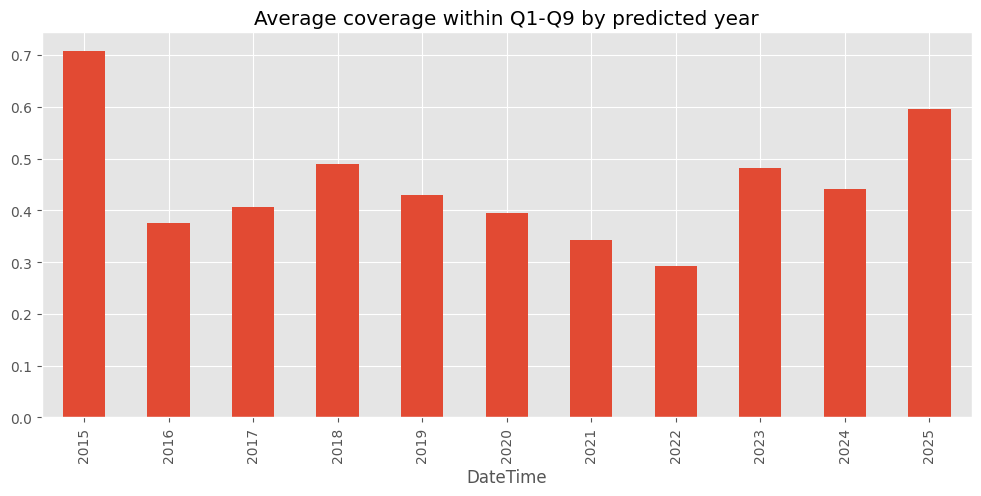

In [ ]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")

df = pd.read_csv(r"output\encdec\20260423012240\predictions.csv", index_col=0, parse_dates=True)
cov = coverage_within_range(df)


fig, ax = plt.subplots(1, figsize=(12,5))
cov.groupby(cov.index.year).mean().plot(kind="bar", ax=ax)
ax.set_title("Average coverage within Q1-Q9 by predicted year")


In [132]:
index = pd.read_csv("index.csv", parse_dates=True, index_col=0)


In [135]:
true = pd.read_csv("input/processed/data.csv", index_col=0, parse_dates=True)["Price"]

Text(0.5, 0.98, 'Average weekly absolute error')

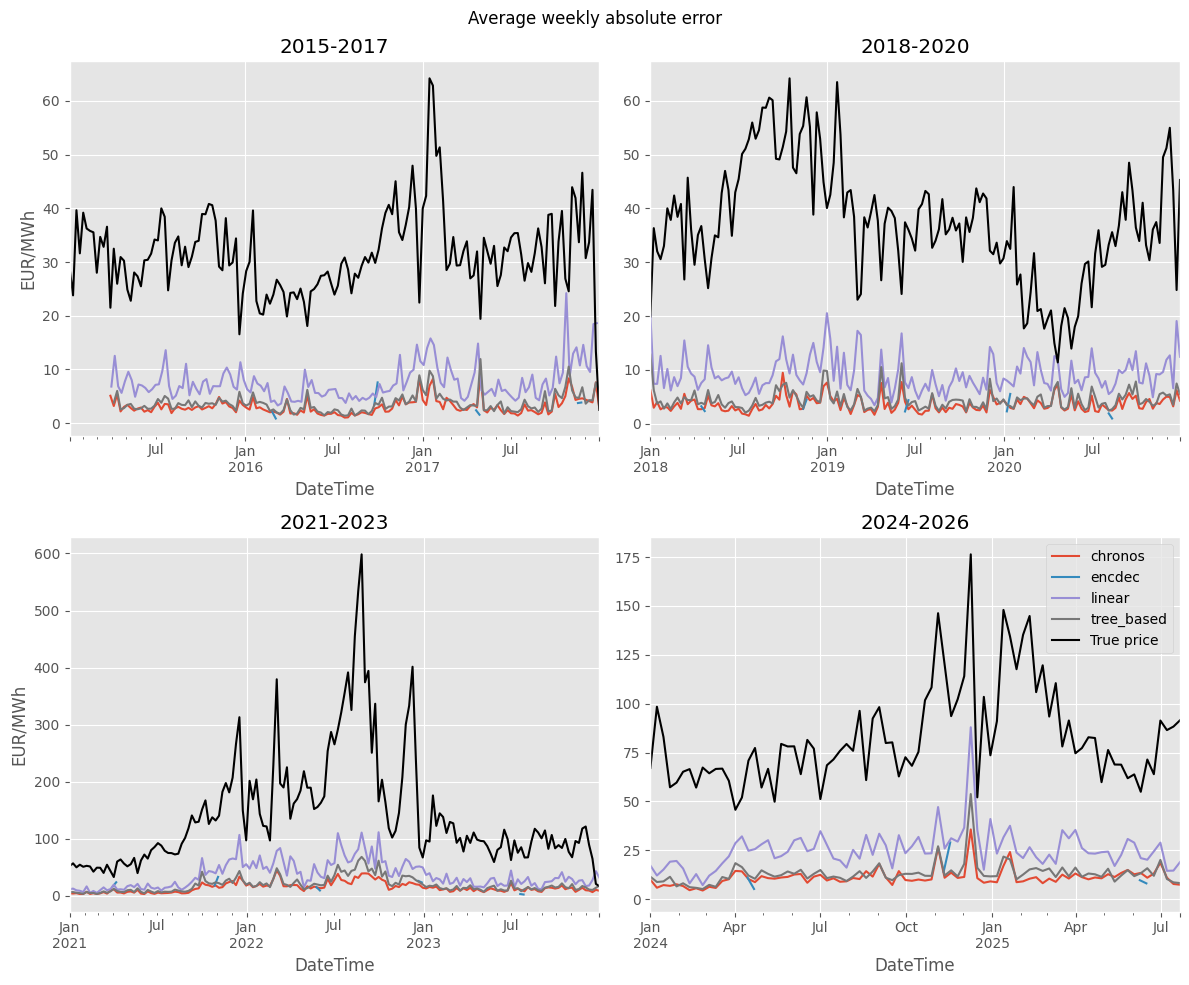

In [176]:
from utils.losses import average_absolute_error
from pathlib import Path

summary_df = pd.read_csv("evaluation_summary.csv", index_col=0)
fig, axes = plt.subplots(2,2, figsize=(12,10), tight_layout=True)


for model in summary_df.index:
    best_run = summary_df.loc[model, "Best_model"]
    pred = pd.read_csv(f"output/{model}/{best_run}/predictions.csv", index_col=0, parse_dates=True)
    err = average_absolute_error(pred)
    # err

    for i in range(4):
        year_err = err[(err.index.year - 2015) // 3 == i]
        year_err_daily = year_err.resample("7d").mean()
        year_err_daily.plot(ax=axes[i//2, i%2], label=model)


true = pd.read_csv("input/processed/data.csv", index_col=0, parse_dates=True)["Price"]
for i in range(4):
    year_true = true[(true.index.year - 2015) // 3 == i]
    year_true_daily = year_true.resample("7d").mean()
    year_true_daily.plot(ax=axes[i//2, i%2], label="True price", color="black")
    axes[i//2, i%2].set_title(f"{2015+i*3}-{2015+i*3+2}")

axes[i//2, i%2].legend()
axes[0,0].set_ylabel("EUR/MWh")
axes[1,0].set_ylabel("EUR/MWh")
fig.suptitle(f"Average weekly absolute error")


    
